# Constrained Optimization using KKT Conditions

## Setup

Import libraries:

In [ ]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown, Latex

Define function for printing optimisation results:

In [ ]:
def print_result(result, st, tol=1e-6):
    x1, x2 = result.x
    print(f"Min: f({x1:.6f}, {x2:.6f}) = {result.fun:.6f}")
    for i, cons in enumerate(st, start=1):
        gval = cons["orig"](result.x)
        status = "active" if abs(gval) <= tol else f"inactive (value {gval:.6e})"
        print(f"Constraint g{i} is {status}")


Define method for showing functions:

In [ ]:
def show_functions(f, st):
  x = np.linspace(-20,20)
  y = np.linspace(-20,20)
  xg, yg = np.meshgrid(x, y)

  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')
  surf = ax.plot_surface(xg, yg, f([xg, yg]), rstride=1, cmap="twilight", linewidth=0, antialiased=False, zorder=20)
  ax.text2D(0.05, 0.95, "Function:", transform=ax.transAxes)
  plt.show()
  print()

  for s in range(len(st)):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(xg, yg, st[s]["orig"]([xg, yg]), rstride=1, cmap="twilight", linewidth=0, antialiased=False, zorder=20)
    ax.text2D(0.05, 0.95, f"Constraint function {s + 1}:", transform=ax.transAxes)
    plt.show()
    print()

Define function for plotting gradients

In [ ]:
def plot_gradient(f, g_list, result, xlim=(-3,3), ylim=(-3,3), title=""):

    x = np.linspace(xlim[0], xlim[1], 400)
    y = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x, y)

    Zf = f([X, Y])
    plt.figure(figsize=(7,6))
    cs = plt.contour(X, Y, Zf, levels=25)
    plt.clabel(cs, inline=True, fontsize=8)

    feasible_mask = np.ones_like(X, dtype=bool)
    for idx, g in enumerate(g_list, start=1):
        Zg = g([X, Y])

        plt.contour(X, Y, Zg, levels=[0], linewidths=2, linestyles='--', label=f"g{idx}=0")
        feasible_mask &= (Zg <= 0)

    plt.contourf(X, Y, feasible_mask, levels=[0.5,1], alpha=0.2)

    if result is not None:
        x1, x2 = result.x
        plt.plot(x1, x2, 'ro', ms=7)

    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.grid(True)
    plt.show()


## Function 1

$ f(x_1, x_2) = (x_1 - 1)^2 + 5(x_2 - 1)^2 $

> $ g(x_1, x_2) = (x_1 + 1)^2 + x_2 ≤ 0 $

Min: f(-0.823205, -0.031256) = 8.641526
Constraint g1 is active




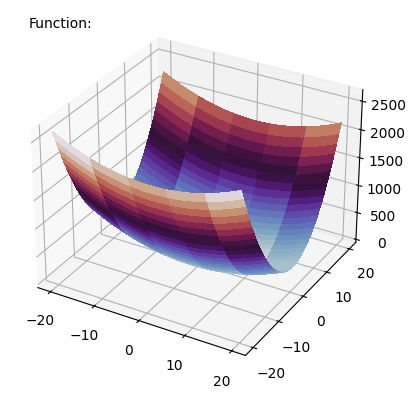

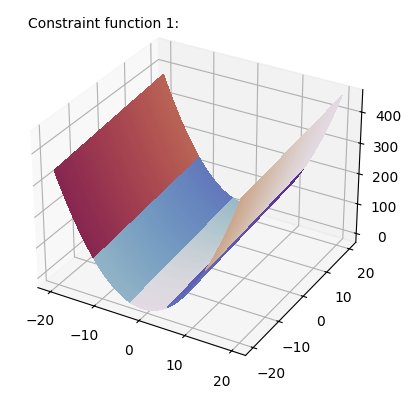

In [ ]:
def f1(x):
  x1 = x[0]
  x2 = x[1]
  return ((x1 - 1)**2) + 5*((x2 - 1)**2)

def g1(x):
  x1 = x[0]
  x2 = x[1]
  return (x1 + 1)**2 + x2

st1 = [{'type':'ineq', 'fun': lambda x : -g1(x), "orig": g1}]

result1 = optimize.minimize(f1, x0=[0, 0], constraints = st1)

print_result(result1, st1)
print("\n")
show_functions(f1, st1)

Then let's check for the KKT conditions:<br>
1.
> $ x_1 - 1 + \lambda_1(x_1 + 1) = 0 $<br>
> $ 10x_2 - 10 + \lambda_1 = 0 $

2.
> $ \lambda_1((x_1 + 1)^2 + x_2) = 0 $

3.
> $ (x_1 + 1)^2 + x_2 \le 0 $

4.
> $ \lambda_1 \ge 0 $

In [ ]:
x1, x2 = result1.x

grad_f = np.array([2*(x1 - 1), 10*(x2 - 1)])
grad_g = np.array([2*(x1 + 1), 1.0])

lam_from_x1 = -(x1 - 1) / (x1 + 1)
lam_from_x2 = -10*(x2 - 1)
lam = lam_from_x2

stationarity_res = np.linalg.norm(grad_f + lam*grad_g)
gval = g1(np.array([x1, x2]))
tol = 1e-8

print("KKT checks — Problem 1")
print(f"x* = ({x1:.8f}, {x2:.8f}),   f(x*) = {f1([x1,x2]):.8f}")
print(f"λ from x1-eq  = {lam_from_x1:.10f}")
print(f"λ from x2-eq  = {lam_from_x2:.10f}")
print(f"|Δλ|           = {abs(lam_from_x1 - lam_from_x2):.3e}   (≈ 0)")
print(f"||∇f + λ∇g||   = {stationarity_res:.3e}                 (≈ 0)")
print(f"g1(x*)         = {gval:.8e}   (≤ 0 required)")
print(f"λ              = {lam:.8f}    (≥ 0 required)")
print(f"λ · g1(x*)     = {(lam*gval):.3e}                      (≈ 0)")
print("Feasible:", gval <= tol,
      "| Dual feasible:", lam >= -1e-12,
      "| Comp. slackness:", abs(lam*gval) <= 1e-6,
      "| Stationarity:", stationarity_res <= 1e-6)


KKT checks — Problem 1
x* = (-0.82320541, -0.03125633),   f(x*) = 8.64152603
λ from x1-eq  = 10.3125635679
λ from x2-eq  = 10.3125632580
|Δλ|           = 3.099e-07   (≈ 0)
||∇f + λ∇g||   = 1.096e-07                 (≈ 0)
g1(x*)         = 7.32241490e-11   (≤ 0 required)
λ              = 10.31256326    (≥ 0 required)
λ · g1(x*)     = 7.551e-10                      (≈ 0)
Feasible: True | Dual feasible: True | Comp. slackness: True | Stationarity: True


Therefore, all KKT conditions are satisfied, $\lambda_1$ is $10.313$.

/tmp/ipython-input-3806238141.py:18: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Zg, levels=[0], linewidths=2, linestyles='--', label=f"g{idx}=0")


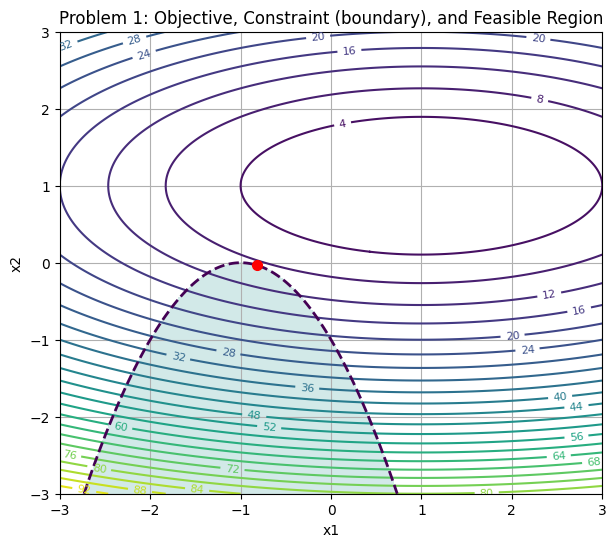

In [ ]:
plot_gradient(
    f1,
    [g1],
    result1,
    xlim=(-3, 3), ylim=(-3, 3),
    title="Problem 1: Objective, Constraint (boundary), and Feasible Region"
)


## Function 2

$ f(x_1, x_2) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2 $

> $ g_1(x_1, x_2) = - x_1 - x_2 ≤ 0 $ <br>
> $ g_2(x_1, x_2) = x_1^2 + x_2^2 -1.5 ≤ 0 $

Min: f(0.907235, 0.822755) = 0.008616
Constraint g1 is inactive (value -1.729989e+00)
Constraint g2 is active




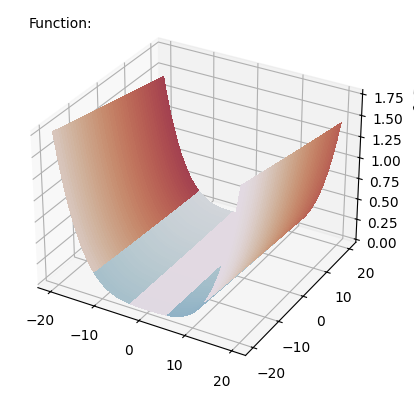

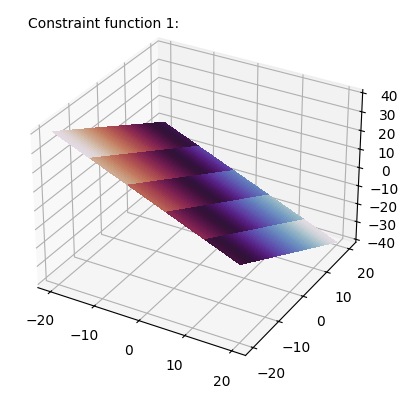

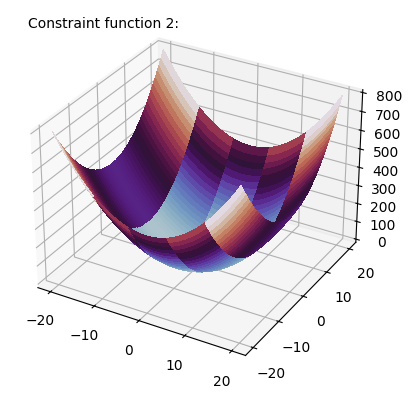

In [ ]:
def f2(x):
  x1 = x[0]
  x2 = x[1]
  return 100*((x2 - x1**2)**2) + (1 - x1)**2

def g2_1(x):
  x1 = x[0]
  x2 = x[1]
  return - x1 - x2

def g2_2(x):
  x1 = x[0]
  x2 = x[1]
  return x1**2 + x2**2 - 1.5

st2 = [{'type':'ineq', 'fun': lambda x : -g2_1(x), "orig": g2_1},
       {'type':'ineq', 'fun': lambda x : -g2_2(x), "orig": g2_2}]

result2 = optimize.minimize(f2, x0=[0, 0], constraints = st2)

print_result(result2, st2)
print("\n")
show_functions(f2, st2)

In [ ]:
x1, x2 = result2.x

grad_f = np.array([
    -400*x1*(x2 - x1**2) - 2*(1 - x1),
     200*(x2 - x1**2)
])
grad_g1 = np.array([-1.0, -1.0])
grad_g2 = np.array([2*x1, 2*x2])

g1_val = g2_1([x1, x2])
g2_val = g2_2([x1, x2])

tol = 1e-8
active = []
A = []
if abs(g1_val) <= tol:
    active.append("g1"); A.append(grad_g1)
if abs(g2_val) <= tol:
    active.append("g2"); A.append(grad_g2)

A = np.column_stack(A) if A else np.zeros((2,0))

if A.shape[1] > 0:
    lam_active, *_ = np.linalg.lstsq(A, -grad_f, rcond=None)
    stationarity_res = np.linalg.norm(grad_f + A @ lam_active)
else:
    lam_active = np.array([])
    stationarity_res = np.linalg.norm(grad_f)

lam1 = 0.0
lam2 = 0.0
k = 0
if "g1" in active:
    lam1 = lam_active[k]; k += 1
if "g2" in active:
    lam2 = lam_active[k]

print("KKT checks — Problem 2")
print(f"x* = ({x1:.8f}, {x2:.8f}),   f(x*) = {f2([x1,x2]):.8f}")
print(f"g1(x*) = {g1_val:.8e}  (≤ 0),   g2(x*) = {g2_val:.8e}  (≤ 0)")
print(f"Active constraints: {active if active else 'none'}")
print(f"λ1 (g1) = {lam1:.8f}  (≥ 0),   λ2 (g2) = {lam2:.8f}  (≥ 0)")
print(f"||∇f + λ1∇g1 + λ2∇g2|| = {stationarity_res:.3e}  (≈ 0)")
print(f"λ1*g1(x*) = {(lam1*g1_val):.3e},   λ2*g2(x*) = {(lam2*g2_val):.3e}  (≈ 0)")
print("Primal feasibility:", (g1_val <= tol) and (g2_val <= tol))
print("Dual feasibility:", (lam1 >= -1e-12) and (lam2 >= -1e-12))
print("Complementary slackness:", (abs(lam1*g1_val) <= 1e-6) and (abs(lam2*g2_val) <= 1e-6))
print("Stationarity:", stationarity_res <= 1e-6)



KKT checks — Problem 2
x* = (0.90723453, 0.82275485),   f(x*) = 0.00861565
g1(x*) = -1.72998938e+00  (≤ 0),   g2(x*) = 3.82708027e-08  (≤ 0)
Active constraints: none
λ1 (g1) = 0.00000000  (≥ 0),   λ2 (g2) = 0.00000000  (≥ 0)
||∇f + λ1∇g1 + λ2∇g2|| = 9.446e-02  (≈ 0)
λ1*g1(x*) = -0.000e+00,   λ2*g2(x*) = 0.000e+00  (≈ 0)
Primal feasibility: False
Dual feasibility: True
Complementary slackness: True
Stationarity: False


/tmp/ipython-input-337384961.py:16: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Zg, levels=[0], linewidths=2, linestyles='--', label=f"g{idx}=0")


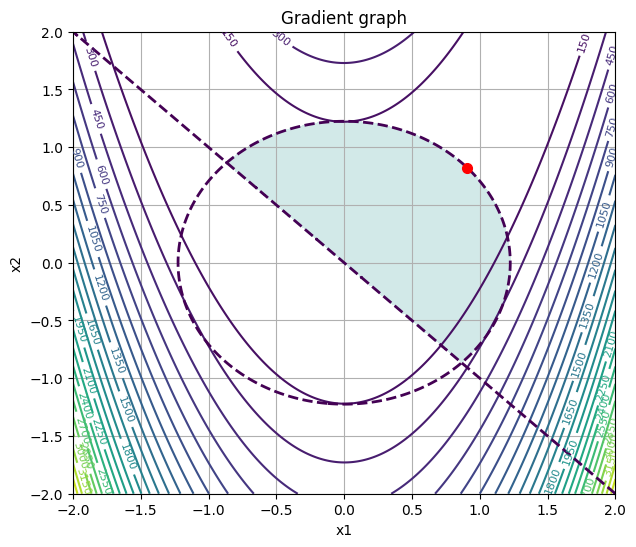

In [ ]:
plot_gradient(
    f2,
    [g2_1, g2_2],
    result2,
    xlim=(-2, 2), ylim=(-2, 2),
    title="Gradient graph"
)


Then let's check for the KKT conditions:<br>
1.
> $ -400x_1x_2 + 400x_1^3 -2 + 2x_1 - \lambda_1 + \lambda_2(2x_1) = 0 $<br>
> $ 200x_2 - 200x_1^2 - \lambda_1 + \lambda_2(2x_2) = 0 $

2.
> $ \lambda_1(- x_1 - x_2) = 0 $<br>
> $ \lambda_2(x_1^2 + x_2^2 - 1.5) = 0 $

3.
> $ - x_1 - x_2 \le 0 $<br>
> $ x_1^2 + x_2^2 - 1.5 \le 0 $

4.
> $ \lambda_1 \ge 0 $<br>
> $ \lambda_2 \ge 0 $

## Custom function 3

$ f(x_1, x_2) = (x_1 - 2)^2 + (x_2+ 1)^2 $

> $ g_1(x_1, x_2) = x_1 + x_2 - 1 ≤ 0 $ <br>
> $ g_2(x_1, x_2) = (x_1-1)^2 + (x_2 - 1)^2 - 4 ≤ 0 $

Min: f(1.822876, -0.822876) = 0.062746
Constraint g1 is active
Constraint g2 is active




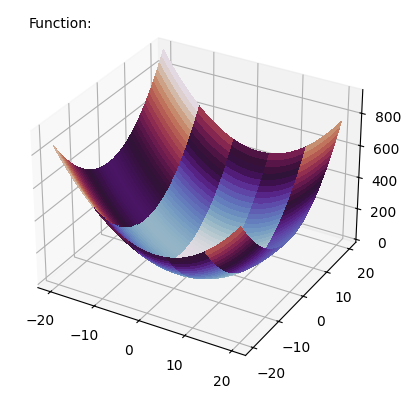

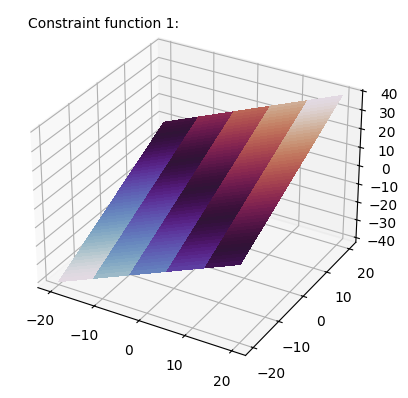

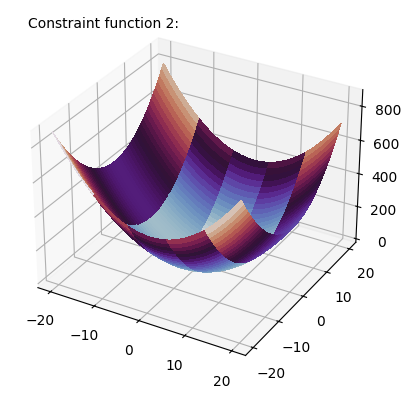

In [ ]:
def f3(x):
    x1, x2 = x
    return (x1 - 2)**2 + (x2 + 1)**2

def g3_1(x):
    x1, x2 = x
    return x1 + x2 - 1

def g3_2(x):
    x1, x2 = x
    return (x1 - 1)**2 + (x2 - 1)**2 - 4

st3 = [
    {'type': 'ineq', 'fun': lambda x: -g3_1(x), "orig": g3_1},
    {'type': 'ineq', 'fun': lambda x: -g3_2(x), "orig": g3_2}
]

result3 = optimize.minimize(f3, x0=[0.0, 0.0], constraints=st3)

print_result(result3, st3)
print("\n")
show_functions(f3, st3)


In [ ]:
x1, x2 = result3.x

grad_f = np.array([2*(x1 - 2), 2*(x2 + 1)])
grad_g1 = np.array([1.0, 1.0])
grad_g2 = np.array([2*(x1 - 1), 2*(x2 - 1)])

g1_val = g3_1([x1, x2])
g2_val = g3_2([x1, x2])

tol = 1e-8
active = []
A = []
if abs(g1_val) <= tol:
    active.append("g1"); A.append(grad_g1)
if abs(g2_val) <= tol:
    active.append("g2"); A.append(grad_g2)
A = np.column_stack(A) if A else np.zeros((2,0))

if A.shape[1] > 0:
    lam_active, *_ = np.linalg.lstsq(A, -grad_f, rcond=None)
    stationarity_res = np.linalg.norm(grad_f + A @ lam_active)
else:
    lam_active = np.array([])
    stationarity_res = np.linalg.norm(grad_f)

lam1 = lam2 = 0.0
k = 0
if "g1" in active:
    lam1 = lam_active[k]; k += 1
if "g2" in active:
    lam2 = lam_active[k]

print("KKT checks — Problem 3")
print(f"x* = ({x1:.8f}, {x2:.8f}),   f(x*) = {f3([x1,x2]):.8f}")
print(f"g1(x*) = {g1_val:.8e},  g2(x*) = {g2_val:.8e}")
print(f"Active constraints: {active if active else 'none'}")
print(f"λ1 (g1) = {lam1:.8f},  λ2 (g2) = {lam2:.8f}")
print(f"||∇f + λ1∇g1 + λ2∇g2|| = {stationarity_res:.3e}")
print(f"λ1*g1(x*) = {(lam1*g1_val):.3e}, λ2*g2(x*) = {(lam2*g2_val):.3e}")
print("Feasible:", (g1_val <= tol) and (g2_val <= tol),
      "| Dual feasible:", (lam1 >= -1e-12) and (lam2 >= -1e-12),
      "| Comp. slackness:", (abs(lam1*g1_val) <= 1e-6) and (abs(lam2*g2_val) <= 1e-6),
      "| Stationarity:", stationarity_res <= 1e-6)


KKT checks — Problem 3
x* = (1.82287573, -0.82287573),   f(x*) = 0.06274601
g1(x*) = 0.00000000e+00,  g2(x*) = 3.87874949e-07
Active constraints: ['g1']
λ1 (g1) = -0.00000000,  λ2 (g2) = 0.00000000
||∇f + λ1∇g1 + λ2∇g2|| = 5.010e-01
λ1*g1(x*) = -0.000e+00, λ2*g2(x*) = 0.000e+00
Feasible: False | Dual feasible: True | Comp. slackness: True | Stationarity: False


/tmp/ipython-input-3806238141.py:18: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Zg, levels=[0], linewidths=2, linestyles='--', label=f"g{idx}=0")


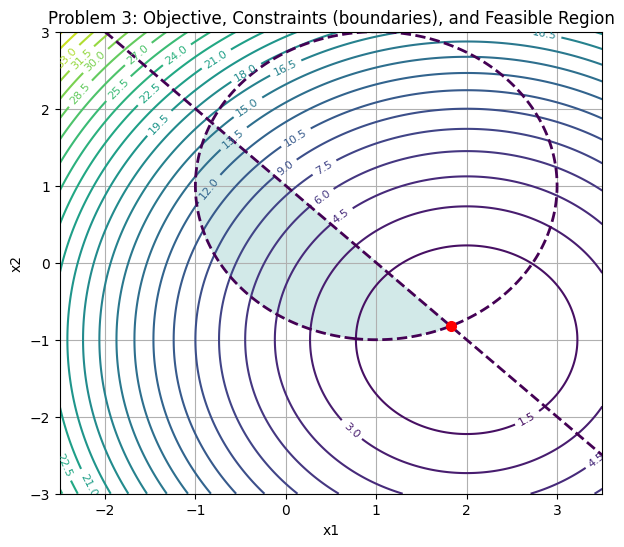

In [ ]:
plot_gradient(
    f3,
    [g3_1, g3_2],
    result3,
    xlim=(-2.5, 3.5), ylim=(-3, 3),
    title="Problem 3: Objective, Constraints (boundaries), and Feasible Region"
)

Min: f(0.800000, 1.600000) = -4.800000
Constraint g1 is active
Constraint g2 is inactive (value -8.000000e-01)




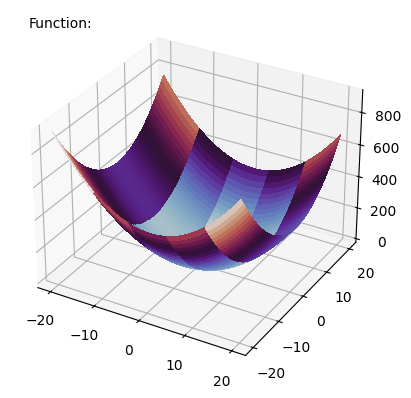

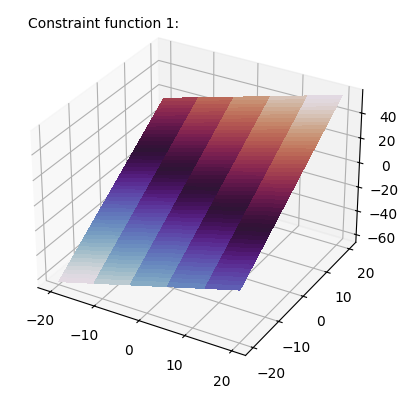

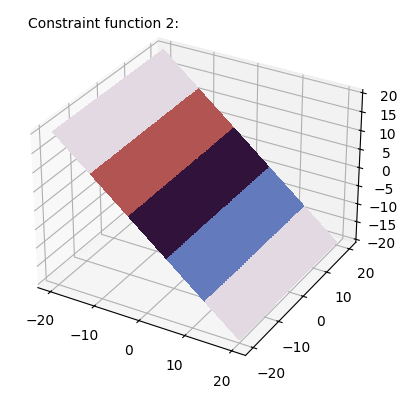

In [ ]:
def f4(x):
    x1, x2 = x
    return x1**2 + x2**2 - 2*x1 - 4*x2

def g4_1(x):
    x1, x2 = x
    return x1 + 2*x2 - 4

def g4_2(x):
    x1, x2 = x
    return -x1

st4 = [
    {'type': 'ineq', 'fun': lambda x: -g4_1(x), "orig": g4_1},
    {'type': 'ineq', 'fun': lambda x: -g4_2(x), "orig": g4_2}
]

result4 = optimize.minimize(f4, x0=[0.0, 0.0], constraints=st4)

print_result(result4, st4)
print("\n")
show_functions(f4, st4)


In [ ]:
x1, x2 = result3.x

grad_f = np.array([2*(x1 - 2), 2*(x2 + 1)])
grad_g1 = np.array([1.0, 1.0])
grad_g2 = np.array([2*(x1 - 1), 2*(x2 - 1)])

g1_val = g3_1([x1, x2])
g2_val = g3_2([x1, x2])

tol = 1e-8
active = []
A = []
if abs(g1_val) <= tol:
    active.append("g1"); A.append(grad_g1)
if abs(g2_val) <= tol:
    active.append("g2"); A.append(grad_g2)
A = np.column_stack(A) if A else np.zeros((2,0))

if A.shape[1] > 0:
    lam_active, *_ = np.linalg.lstsq(A, -grad_f, rcond=None)
    stationarity_res = np.linalg.norm(grad_f + A @ lam_active)
else:
    lam_active = np.array([])
    stationarity_res = np.linalg.norm(grad_f)

lam1 = lam2 = 0.0
k = 0
if "g1" in active:
    lam1 = lam_active[k]; k += 1
if "g2" in active:
    lam2 = lam_active[k]

print("KKT checks — Problem 3")
print(f"x* = ({x1:.8f}, {x2:.8f}),   f(x*) = {f3([x1,x2]):.8f}")
print(f"g1(x*) = {g1_val:.8e},  g2(x*) = {g2_val:.8e}")
print(f"Active constraints: {active if active else 'none'}")
print(f"λ1 (g1) = {lam1:.8f},  λ2 (g2) = {lam2:.8f}")
print(f"||∇f + λ1∇g1 + λ2∇g2|| = {stationarity_res:.3e}")
print(f"λ1*g1(x*) = {(lam1*g1_val):.3e}, λ2*g2(x*) = {(lam2*g2_val):.3e}")
print("Feasible:", (g1_val <= tol) and (g2_val <= tol),
      "| Dual feasible:", (lam1 >= -1e-12) and (lam2 >= -1e-12),
      "| Comp. slackness:", (abs(lam1*g1_val) <= 1e-6) and (abs(lam2*g2_val) <= 1e-6),
      "| Stationarity:", stationarity_res <= 1e-6)


KKT checks — Problem 3
x* = (1.82287573, -0.82287573),   f(x*) = 0.06274601
g1(x*) = 0.00000000e+00,  g2(x*) = 3.87874949e-07
Active constraints: ['g1']
λ1 (g1) = -0.00000000,  λ2 (g2) = 0.00000000
||∇f + λ1∇g1 + λ2∇g2|| = 5.010e-01
λ1*g1(x*) = -0.000e+00, λ2*g2(x*) = 0.000e+00
Feasible: False | Dual feasible: True | Comp. slackness: True | Stationarity: False
